In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

<h1>CUP — Ensemble OOF</h1>
<p>This notebook combines the most proficient model implemented in their corresponding notebooks:
<ul>
<li>KNN: cup_KNN.ipynb
<li>SVR: cup_SVM.ipynb
<li>NN : cup_NN_manual`</li>
 </ul>
 while LinearSVR and other models are excluded because they received zero weight or performed poorly during model selection. The procedure separates the 500 labelled samples into a 400-sample development set and a 100-sample internal test set. OOF predictions and non-negative ensemble weights are computed only on development data. The frozen ensemble is evaluated once on the internal test, then retrained on all 500 labelled samples to produce the official blind-test predictions.
</p>
<hr/>

In [2]:
from pathlib import Path
from functools import partial
import copy
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.optimize import minimize
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR, SVR

import cup_common as cc
import cross_common as cr
import nn_common as nnc

warnings.filterwarnings("ignore", category=ConvergenceWarning)
SEED = 42
N_SPLITS = 5
torch.manual_seed(SEED)
np.random.seed(SEED)

TRAINING_SEED = 1
CV_RANDOM_STATE = 42

nnc.set_global_seed(TRAINING_SEED)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h2>Preparation</h2>

<h3>Data Loading</h3>

In [3]:
df_train, df_test = cc.load_set()
X_full, y_full = cc.prepare_dataset(df_train)
X_development, y_development, X_internal, y_internal = cc.prepare_dataset_for_hold_out(
    df_train, random_state=cc.INTERNAL_TEST_RANDOM_STATE
)
X_test, _ = cc.prepare_dataset(df_test)
test_ids = df_test["id"].to_numpy()
print(f"Development samples: {len(X_development)}")
print(f"Internal-test samples: {len(X_internal)}")
print(f"Blind-test samples: {len(X_test)}")

Development samples: 400
Internal-test samples: 100
Blind-test samples: 1000


<h3>Hyperparameters</h3>
<p>The configuration below is taken from the latest and most proficient run on their specific models.
</p>
<p>Note: scikit-learn clone the scaler by default at each run</p>

<h4>Scikit-learn configuration</h4>
<p>See the corresponding KNN: cup_KNN.ipynb and SVR: cup_SVM.ipynb notebooks for details about the parameters below.</p>

In [4]:
best_sklearn_grid_params = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=3, weights="uniform", p=2)),
    ]),
    "SVR_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MultiOutputRegressor(SVR(kernel="rbf", C=30, gamma=3, epsilon=0.1))),
    ]),
    # Initially included but then excluded because of zero weight
    # "LinearSVR": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("model", MultiOutputRegressor(
    #         LinearSVR(C=0.01, dual=False, loss="squared_epsilon_insensitive",
    #                   max_iter=20_000, random_state=SEED)
    #     )),
    # ]),
}


<h4>NN Configuration</h4>
<p>See the corresponding NN: cup_NN_manual.ipynb notebook for details about the parameters below.</p>

In [5]:
# # Best Optuna configuration verified
# in cup_NN_manual.ipynb (run_2_selected_config)
nn_config = {
    "hidden_layers": [128, 64],
    "activation": "gelu",
    "batch_size": 16,
    "learning_rate": 0.0467814685218321,
    "weight_decay": 0.006545327900225643,
}

epochs = 1000
batch_size = nn_config["batch_size"]
learning_rate = nn_config["learning_rate"]
weight_decay = nn_config["weight_decay"]
hidden_layers = nn_config["hidden_layers"]
activation = nn_config["activation"]

# The seed to be used by data splitter
default_state = cr.RANDOM_STATE
default_seed = cr.SEED


# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_development.shape[1]
output_dimension = 4


# ----- Defining model architecture --------
hidden_layers = hidden_layers
net = nnc.build_nn_net(input_dimension, output_dimension, hidden_layers, activation)

# The output and loss function, must be changed according to the type of task
loss_function = nnc.MEELoss()
output_adapter = nnc.regression_adapter()

# Model implementation
model_template = nnc.build_nn_model(net, output_adapter)
# ------------------------------------------


# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=learning_rate,
    weight_decay=weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by learning rate will decrease
learning_rate_decay_factor = 0.5
# The epoch to wait before applying the rate decay factor
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", threshold_mode = "abs", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = nnc.EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------

nn_train_params = {
    "epochs": epochs,
    "batch_size": batch_size,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "scheduler_template": scheduler_template,
    "early_stopping_strategy": early_stopping_strategy,
    "silence_output": True,
}


In [6]:
all_model_names = [*best_sklearn_grid_params, "NN"]
print(all_model_names)

['KNN', 'SVR_RBF', 'NN']


<h2>Out-of-fold prediction</h2>

<h3>KFold</h3>
<p>Perform KFold on models by reusing the existing specific KFold function as in cross_common and nn_common.</p>

In [7]:
# fold strategy by defaul returns 5 split with 42 as random seeds
#KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
cv = cr.common_fold_strategy()
metrics = {cr.MEE: (cr.mee, min)}

# OOF predictions holders
oof_predictions = {
    name: np.zeros_like(y_development, dtype=float) for name in all_model_names
}

# Gather all the final scores per model
fold_scores = {name: [] for name in all_model_names}

<h4>Scikit-learn</h4>

In [8]:
# KNN e SVR reuse the same runner and the same cr.kfold of the original notebooks.
sklearn_fold_results = {}
for name, estimator in best_sklearn_grid_params.items():
    runner = cr.SklearnRegressorRunner(estimator)
    results = cr.kfold(runner, X_development, y_development, cv, metrics=metrics)
    sklearn_fold_results[name] = results
    for fold_result in results:
        oof_predictions[name][fold_result.vl_indices] = fold_result.vl_predictions
        fold_scores[name].append(fold_result.fold_vl_mee)

  
Perform fold: 1, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 18.0120
Train                | samples: 320
Validation           | samples: 80
  
Perform fold: 2, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 15.9717
Train                | samples: 320
Validation           | samples: 80
  
Perform fold: 3, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 15.4871
Train                | samples: 320
Validation           | samples: 80
  
Perform fold: 4, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 16.6382
Train                | samples: 320
Validation           | samples: 80
  
Perfo

<h4>Neural Network</h4>

In [9]:
# NN reuse the same nnc.kfold of the original notebooks.
model_kf = copy.deepcopy(model_template)
nn_fold_results = nnc.kfold(
    model_kf, X_development, y_development, cv,
    copy.deepcopy(nn_train_params), StandardScaler(),
)

# gathering single fold prediction
for fold_result in nn_fold_results:
    oof_predictions["NN"][fold_result.vl_indices] = fold_result.vl_predictions
    fold_scores["NN"].append(fold_result.fold_vl_loss)

# Train criteria for the final model
nn_training_losses_at_best = [fold_result.fold_tr_loss for fold_result in nn_fold_results]

<h4>Scores</h4>

,OOF MEE
KNN,16.322268
SVR_RBF,17.784311
NN,20.277949


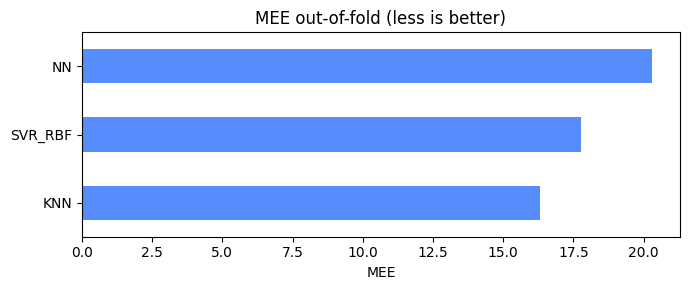

In [10]:
oof_scores = pd.Series(
    {name: cr.mee(y_development, pred) for name, pred in oof_predictions.items()},
    name="OOF MEE",
).sort_values()
display(oof_scores.to_frame())

# Graph score
ax = oof_scores.plot.barh(figsize=(7, 3), title="MEE out-of-fold (less is better)")
ax.set_xlabel("MEE")
plt.tight_layout()
plt.show()

<h4>Weight Optimization</h4>
<p>
The ensemble weights are estimated using the out-of-fold predictions generated during cross-validation. Each weight is constrained to be non-negative, and all weights must sum to one, resulting in a convex combination of the individual model predictions.
</p>
<p>
The optimization minimizes the official project metric Mean Euclidean Error (MEE) between the development targets and the blended OOF predictions. Neither the internal test nor the official blind test is involved in weight selection.
</p>
<p>
A model may receive a small or zero weight when its predictions do not improve the ensemble beyond the contribution of the other models. Therefore, inclusion in the initial pool does not guarantee participation in the final ensemble.
</p>

In [11]:
model_names = list(oof_predictions)
oof_stack = np.stack([oof_predictions[name] for name in model_names], axis=0)

# Compute predictions
def blend_predictions(stack, weights):
    return np.tensordot(weights, stack, axes=(0, 0))

# The objective function to determine weights
def objective(weights):
    return cr.mee(y_development, blend_predictions(oof_stack, weights))

initial_weights = np.full(len(model_names), 1 / len(model_names))
result = minimize(
    objective,
    x0=initial_weights,
    method="SLSQP",
    bounds=[(0.0, 1.0)] * len(model_names),
    constraints={"type": "eq", "fun": lambda w: w.sum() - 1.0},
    options={"maxiter": 2_000, "ftol": 1e-10},
)

if not result.success:
    raise RuntimeError(f"Optimization failed: {result.message}")

weights = result.x / result.x.sum()
weights_table = pd.Series(weights, index=model_names, name="Weight").sort_values(ascending=False)
oof_ensemble = blend_predictions(oof_stack, weights)
display(weights_table.to_frame())
print(f"MEE OOF ensemble: {cr.mee(y_development, oof_ensemble):.4f}")
print(f"Best score:  {oof_scores.min():.4f} ({oof_scores.idxmin()})")

,Weight
KNN,0.742576
SVR_RBF,0.169596
NN,0.087828


MEE OOF ensemble: 16.0993
Best score:  16.3223 (KNN)


<h4>OOF Error Correlation</h4>
<p>
The correlation between the out-of-fold prediction errors of the individual models is analyzed to evaluate their diversity. Models with weakly correlated errors tend to make different mistakes and may therefore complement each other effectively within the ensemble.
</p>
<p>
Conversely, a high positive correlation indicates that two models often make similar errors, reducing the potential benefit of combining their predictions. Error correlation should be considered together with each model's OOF performance, since a diverse but inaccurate model may still provide little or no improvement to the final ensemble.
</p>

In [12]:
# Compute the prediction errors of each model on development OOF data.
# the OOF predictions from the corresponding true target values.
# The multi-output error matrices are flattened into one-dimensional
# vectors so that correlations can be calculated across all samples
# and target components.
flat_errors = {
    name: (y_development - pred).ravel()
    for name, pred in oof_predictions.items()
}

# Organize the flattened error vectors into a DataFrame, where each
# column represents the OOF errors produced by one model. Then compute
# the pairwise Pearson correlation coefficients between the models.
error_correlation = pd.DataFrame(flat_errors).corr()

# Display the resulting correlation matrix rounded to three decimal
# places for readability.
display(error_correlation.round(3))

,KNN,SVR_RBF,NN
KNN,1.000,0.849,0.702
SVR_RBF,0.849,1.000,0.748
NN,0.702,0.748,1.000


<h3>Internal Test Evaluation and Final Prediction</h3>
<p>
The ensemble configuration and its weights are frozen after OOF model selection on the 400-sample development set. Each component is first retrained on those 400 samples and evaluated once on the 100-sample internal test set, which has not been used for hyperparameter or weight selection.
</p>
<p>
After the internal assessment, the unchanged models are retrained on all 500 labelled samples. Their blind-test predictions are combined using the same frozen OOF weights to produce the CUP submission.
</p>

In [13]:
# the checkpoint for NN training (see cup_NN.ipynb for details)
nn_target_training_loss = float(np.mean(nn_training_losses_at_best))

# Iterate scikit learn models and NN model
def fit_and_predict_models(X_fit, y_fit, X_predict, seed:int):
    fitted = {}
    predictions = {}
    fit_predictions = {}
    nnc.set_global_seed(seed)

    # The sklearn pipelines fit their scaler only on X_fit.
    for name, template in best_sklearn_grid_params.items():
        fitted[name] = clone(template).fit(X_fit, y_fit)
        predictions[name] = fitted[name].predict(X_predict)
        fit_predictions[name] = fitted[name].predict(X_fit)

    # The NN scaler is also fitted exclusively on X_fit.
    nn_scaler = StandardScaler().fit(X_fit)
    X_fit_nn = pd.DataFrame(nn_scaler.transform(X_fit), columns=X_fit.columns)
    X_predict_nn = pd.DataFrame(nn_scaler.transform(X_predict), columns=X_predict.columns)

    nn_model = copy.deepcopy(model_template)
    nn_final_params = copy.deepcopy(nn_train_params)
    nn_final_params.pop("scheduler_template")
    nn_final_params.pop("early_stopping_strategy")
    nn_final_params["train_control"] = nn_target_training_loss
    nnc.train(
        nn_model,
        nnc.FullTrainingStrategy(nnc.FeatureTargetSet(X_fit_nn, y_fit)),
        **nn_final_params,
    )
    fitted["NN"] = nn_model
    predictions["NN"] = nn_model.predict(X_predict_nn)[0].detach().cpu().numpy()
    fit_predictions["NN"] = nn_model.predict(X_fit_nn)[0].detach().cpu().numpy()
    return fitted, predictions, fit_predictions

# Independent internal-test assessment: fit on 400, predict the held-out 100.
internal_models, internal_predictions, development_predictions = fit_and_predict_models(
    X_development, y_development, X_internal, TRAINING_SEED
)
internal_stack = np.stack([internal_predictions[name] for name in model_names], axis=0)
y_pred_internal_ensemble = blend_predictions(internal_stack, weights)

# Training MEE of the frozen ensemble fitted on the 400-sample development set.
development_stack = np.stack(
    [development_predictions[name] for name in model_names], axis=0
)
y_pred_development_ensemble = blend_predictions(development_stack, weights)

# Final CUP training: refit the frozen configuration on all 500 labelled samples.
fitted_models, test_predictions, _ = fit_and_predict_models(X_full, y_full, X_test, TRAINING_SEED)
test_stack = np.stack([test_predictions[name] for name in model_names], axis=0)
y_pred_ensemble = blend_predictions(test_stack, weights)
assert y_pred_internal_ensemble.shape == (len(X_internal), 4)
assert y_pred_ensemble.shape == (len(X_test), 4)
y_pred_ensemble[:5]


array([[ -2.63599983,  -2.24528047,   6.65160527,  -6.17371169],
       [ -9.58962962,  -2.09367272, -45.67738944,   8.21112217],
       [ -2.37700498,  -3.08493951,  -3.58167981,   6.50539709],
       [ -4.26136095,  11.70572757, -28.36547012,   8.67236959],
       [  3.61496939,  -9.14492368, -22.92671007,  21.50333753]])

<h4>Final MEE Summary</h4>
<p>The table below compares the training, out-of-fold validation, and independent internal-test MEE of each component model and of the frozen ensemble. Training MEE is an in-sample measure, while OOF and internal-test MEE provide progressively more independent estimates of generalization performance.</p>

In [14]:
internal_scores = pd.Series(
    {
        **{
            name: cr.mee(y_internal, pred)
            for name, pred in internal_predictions.items()
        },
        "Ensemble": cr.mee(y_internal, y_pred_internal_ensemble),
    },
    name="Internal Test MEE",
).sort_values()

training_scores = {
    **{
        name: cr.mee(y_development, pred)
        for name, pred in development_predictions.items()
    },
    "Ensemble": cr.mee(y_development, y_pred_development_ensemble),
}

oof_summary_scores = {
    **oof_scores.to_dict(),
    "Ensemble": cr.mee(y_development, oof_ensemble),
}

mee_summary = pd.DataFrame({
    "Training MEE": training_scores,
    "OOF Validation MEE": oof_summary_scores,
    "Internal Test MEE": internal_scores.to_dict(),
}).loc[[*model_names, "Ensemble"]]

display(mee_summary.round(4))

,Training MEE,OOF Validation MEE,Internal Test MEE
KNN,10.5313,16.3223,16.8191
SVR_RBF,2.3408,17.7843,17.8229
NN,15.5079,20.2779,21.7458
Ensemble,9.0248,16.0993,16.5450


<h4>Frozen Ensemble Learning Curve</h4>
<p>The final ensemble has no epoch-based training process. Its learning curve is therefore evaluated as a function of the training-set size. The component hyperparameters and OOF-derived ensemble weights remain frozen, and only development-set folds are used. The internal test is shown once as a final reference and is not used to construct or select the curve.</p>

,Training size,Training MEE mean,Training MEE std,Validation MEE mean,Validation MEE std
0,80,12.3615,0.6632,22.4497,2.0183
1,160,10.8229,0.6272,19.0322,1.1158
2,240,9.9030,0.2377,17.1758,0.8280
3,320,9.4300,0.1676,16.1814,0.9015


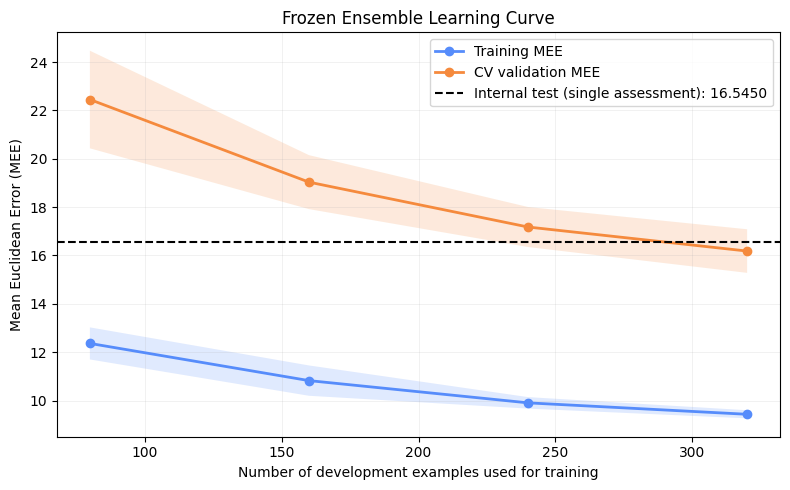

In [15]:
# Post-selection diagnostic: the model configurations and ensemble weights
# are frozen. Neither the internal test nor the blind test is used for fitting.
TRAIN_FRACTIONS = np.array([0.25, 0.50, 0.75, 1.00])
learning_curve_cv = cr.common_fold_strategy(
    n_split=N_SPLITS, shuffle=True, random_state=SEED
)

def take_rows(values, indices):
    # Preserve pandas column names when available; NN scaling relies on them.
    return values.iloc[indices] if hasattr(values, "iloc") else values[indices]

curve_records = []

for fold_number, (fold_train_indices, fold_val_indices) in enumerate(
    learning_curve_cv.split(X_development), start=1
):
    # One deterministic permutation per fold makes the training subsets nested:
    # every larger subset contains all observations used by the smaller subset.
    fold_rng = np.random.default_rng(SEED + fold_number)
    ordered_train_indices = fold_rng.permutation(fold_train_indices)

    X_fold_val = take_rows(X_development, fold_val_indices)
    y_fold_val = take_rows(y_development, fold_val_indices)

    for fraction in TRAIN_FRACTIONS:
        train_size = max(2, int(round(len(ordered_train_indices) * fraction)))
        subset_indices = ordered_train_indices[:train_size]
        X_fold_train = take_rows(X_development, subset_indices)
        y_fold_train = take_rows(y_development, subset_indices)

        _, fold_val_predictions, fold_train_predictions = fit_and_predict_models(
            X_fold_train, y_fold_train, X_fold_val, TRAINING_SEED
        )

        fold_train_stack = np.stack(
            [fold_train_predictions[name] for name in model_names], axis=0
        )
        fold_val_stack = np.stack(
            [fold_val_predictions[name] for name in model_names], axis=0
        )
        fold_train_ensemble = blend_predictions(fold_train_stack, weights)
        fold_val_ensemble = blend_predictions(fold_val_stack, weights)

        curve_records.append({
            "Fold": fold_number,
            "Training size": train_size,
            "Training MEE": cr.mee(y_fold_train, fold_train_ensemble),
            "Validation MEE": cr.mee(y_fold_val, fold_val_ensemble),
        })

learning_curve_scores = pd.DataFrame(curve_records)
learning_curve_summary = (
    learning_curve_scores
    .groupby("Training size", as_index=False)
    .agg({
        "Training MEE": ["mean", "std"],
        "Validation MEE": ["mean", "std"],
    })
)
learning_curve_summary.columns = [
    "Training size",
    "Training MEE mean", "Training MEE std",
    "Validation MEE mean", "Validation MEE std",
]

display(learning_curve_summary.round(4))

sizes = learning_curve_summary["Training size"].to_numpy()
train_mean = learning_curve_summary["Training MEE mean"].to_numpy()
train_std = learning_curve_summary["Training MEE std"].to_numpy()
val_mean = learning_curve_summary["Validation MEE mean"].to_numpy()
val_std = learning_curve_summary["Validation MEE std"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, train_mean, marker="o", linewidth=2, label="Training MEE")
ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.18)
ax.plot(sizes, val_mean, marker="o", linewidth=2, label="CV validation MEE")
ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.18)
ax.axhline(
    internal_scores["Ensemble"], color="black", linestyle="--",
    label=f"Internal test (single assessment): {internal_scores['Ensemble']:.4f}"
)
ax.set_title("Frozen Ensemble Learning Curve")
ax.set_xlabel("Number of development examples used for training")
ax.set_ylabel("Mean Euclidean Error (MEE)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

<h4>CUP Submission File</h4>
<p>The cell below generates the final blind-test file in the ML-CUP submission format.</p>

In [16]:
TEAM_NICKNAME = "CDM25"
TEAM_MEMBERS = "Leonardo Celati, Damiano Degliotti, Daniele Melaccio"
CUP_ID="ML-CUP25 v1"
SUBMISSION_DATE = "2026-08-15"

output_dir = Path("ensemble_outputs")
output_dir.mkdir(exist_ok=True)
cup_path = output_dir / f"{TEAM_NICKNAME}_ML-CUP25-TS.csv"

submission = pd.DataFrame(y_pred_ensemble)
submission.insert(0, "id", test_ids.astype(int))

cup_header = [
    f"# {TEAM_MEMBERS}",
    f"# {TEAM_NICKNAME}",
    f"# {CUP_ID}",
    f"# {SUBMISSION_DATE}",
]
with cup_path.open("w", encoding="utf-8", newline="") as cup_file:
    cup_file.write("\n".join(cup_header) + "\n")
    submission.to_csv(cup_file, index=False, header=False)

assert submission.shape == (len(X_test), 5)
assert submission["id"].tolist() == test_ids.astype(int).tolist()
display(submission.head())
print(f"CUP submission saved to: {cup_path.resolve()}")

,id,0,1,2,3
0,1,-2.636000,-2.245280,6.651605,-6.173712
1,2,-9.589630,-2.093673,-45.677389,8.211122
2,3,-2.377005,-3.084940,-3.581680,6.505397
3,4,-4.261361,11.705728,-28.365470,8.672370
4,5,3.614969,-9.144924,-22.926710,21.503338


CUP submission saved to: /Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/ensemble_outputs/CDM25_ML-CUP25-TS.csv


## Note

- Se l'ensemble OOF non supera il miglior modello singolo, usa il miglior modello singolo: l'ensemble non è automaticamente migliore.
- La rete neurale usa la configurazione di `cup_NN_manual.ipynb` e viene reinizializzata in ogni fold.
- Per una stima più rigorosa delle prestazioni dell'intera procedura di scelta dei pesi servirebbe una cross-validation esterna; questa versione è pensata per costruire l'ensemble finale in modo semplice e riproducibile.